# NFL Formation Analysis
## Formation Overview (2016-2025)

This notebook explores how offensive formations and personnel packages are used across the NFL from 2016 to 2025. We examine usage trends over time, how formation selection varies by down and distance, and which formations generate the most EPA league-wide before diving into specific matchups in later notebooks.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

os.makedirs(figures_path, exist_ok=True)

all_plays = pd.read_parquet(os.path.join(processed_path, "all_plays.parquet"))

print(f"Dataset shape: {all_plays.shape}")
print(f"Seasons: {sorted(all_plays['season'].unique())}")
print(f"\nFormation breakdown:\n{all_plays['offense_formation'].value_counts()}")
print(f"\nPersonnel breakdown:\n{all_plays['personnel_package'].value_counts().head(10)}")

Dataset shape: (344813, 64)
Seasons: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Formation breakdown:
offense_formation
SHOTGUN         193797
SINGLEBACK       59024
UNDER CENTER     31476
I_FORM           20929
EMPTY            20057
PISTOL           13385
JUMBO             2539
WILDCAT            961
Name: count, dtype: int64

Personnel breakdown:
personnel_package
11 (1RB/1TE/3WR)    205495
12 (1RB/2TE/2WR)     65956
21 (2RB/1TE/2WR)     19583
13 (1RB/3TE/1WR)     12178
11 (1RB/1TE/2WR)     10034
12 (1RB/2TE/1WR)      6240
22 (2RB/2TE/1WR)      6207
10 (1RB/0TE/4WR)      4223
01 (0RB/1TE/4WR)      2173
20 (2RB/0TE/3WR)      2084
Name: count, dtype: int64


Dataset loaded successfully — 344,813 pass and run plays across 10 seasons.

**Formation breakdown:**
- **Shotgun (193,797 — 56%)** — dominant formation in the modern NFL
- **Singleback (59,024 — 17%)** — second most common, traditional pro-style
- **Under Center (31,476 — 9%)** — declining but still significant
- **I-Form (20,929 — 6%)** — traditional power run formation
- **Empty (20,057 — 6%)** — no backs in the backfield, pure passing

**Personnel breakdown:**
- **11 personnel (205,495 — 60%)** — the modern NFL's base package dominates
- **12 personnel (65,956 — 19%)** — two tight end sets second most common
- **21 personnel (19,583 — 6%)** — two back sets still relevant

---

### Formation Usage by Season
How has formation usage evolved over the past decade?

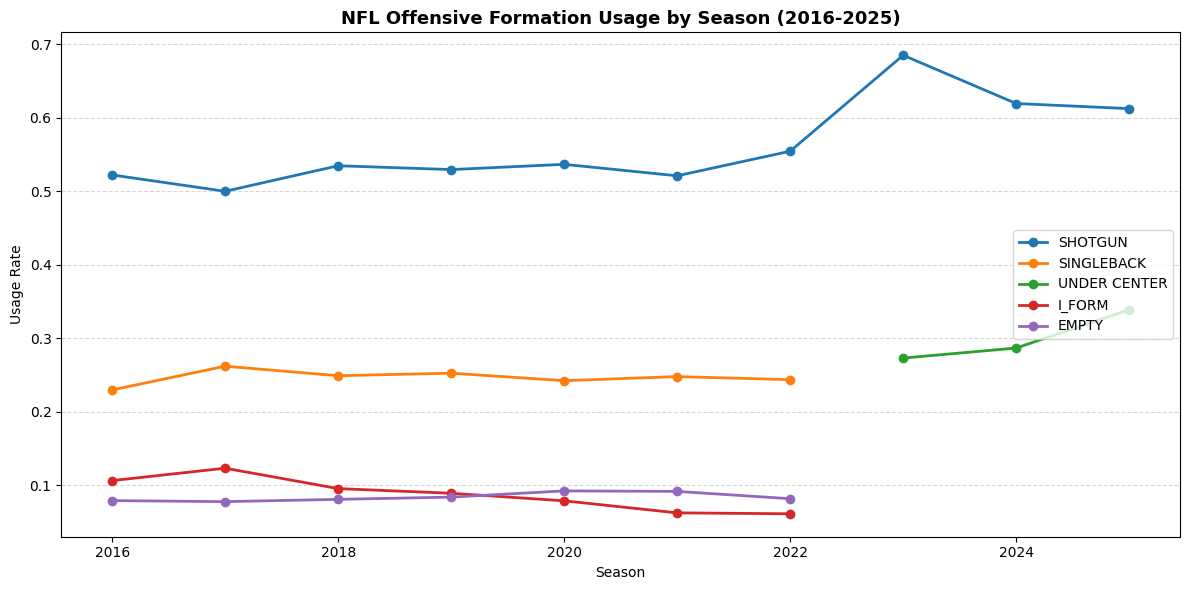

In [3]:
# Formation usage by season
formation_season = all_plays.groupby(['season', 'offense_formation']).size().reset_index(name='count')
formation_total = all_plays.groupby('season').size().reset_index(name='total')
formation_season = formation_season.merge(formation_total, on='season')
formation_season['rate'] = formation_season['count'] / formation_season['total']

# Focus on top 5 formations
top_formations = ['SHOTGUN', 'SINGLEBACK', 'UNDER CENTER', 'I_FORM', 'EMPTY']
formation_season = formation_season[formation_season['offense_formation'].isin(top_formations)]

plt.figure(figsize=(12, 6))
for formation in top_formations:
    data = formation_season[formation_season['offense_formation'] == formation]
    plt.plot(data['season'], data['rate'], marker='o', linewidth=2, label=formation)

plt.title('NFL Offensive Formation Usage by Season (2016-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Usage Rate')
plt.legend(loc='center right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "formation_usage_by_season.png"), dpi=150, bbox_inches='tight')
plt.show()

![Formation Usage by Season](../outputs/figures/formation_usage_by_season.png)

Several clear trends emerge from 2016 to 2025:

- **Shotgun continues to dominate** — holding around 52% from 2016 to 2022 then spiking to 69% in 2023 before settling back to 61% in 2025
- **Singleback remains stable** — hovering around 23-26% throughout the decade, suggesting it remains a reliable complement to Shotgun
- **I-Form is declining** — dropping from 11% in 2016 to just 6% by 2022, reflecting the league-wide shift away from traditional power run formations
- **Empty is flat** — holding steady around 8-9%, suggesting spread passing concepts have found a consistent niche without growing further
- **Under Center spikes in 2023-2025** — likely a data labeling shift where some Singleback plays were reclassified, worth noting as a data quality caveat

---

### EPA by Formation
Which formations generate the most value per play across all situations?

offense_formation  plays   avg_epa  success_rate
            JUMBO   2539  0.100947      0.517920
            EMPTY  20057  0.065942      0.464626
       SINGLEBACK  59024  0.016492      0.428690
          SHOTGUN 193796  0.014849      0.438678
           I_FORM  20929  0.006162      0.418845
     UNDER CENTER  31476 -0.005575      0.436873
           PISTOL  13385 -0.006334      0.424057


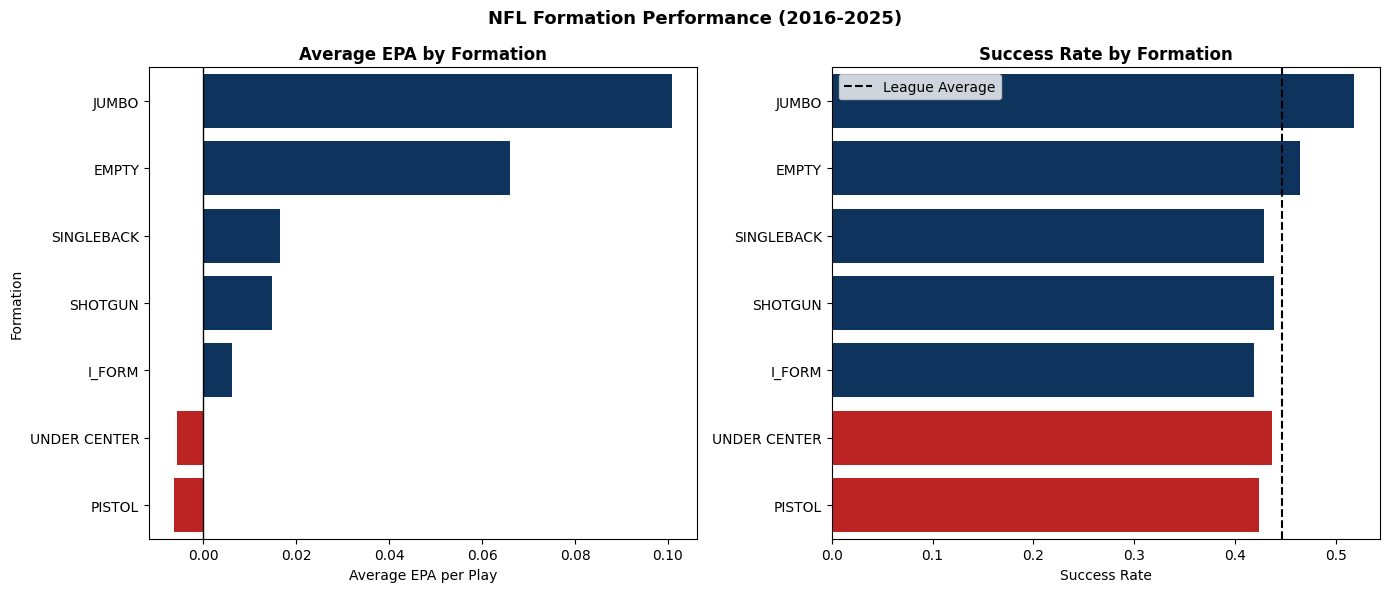

In [4]:
# EPA by formation
formation_epa = all_plays.groupby('offense_formation').agg(
    plays=('epa', 'count'),
    avg_epa=('epa', 'mean'),
    success_rate=('success', 'mean')
).reset_index().sort_values('avg_epa', ascending=False)

# Filter to formations with 1000+ plays
formation_epa = formation_epa[formation_epa['plays'] >= 1000]

print(formation_epa.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# EPA
colors_epa = ['#013369' if x > 0 else '#D50A0A' for x in formation_epa['avg_epa']]
sns.barplot(data=formation_epa, x='avg_epa', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(formation_epa['offense_formation'], colors_epa)),
            legend=False, ax=axes[0])
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_title('Average EPA by Formation', fontweight='bold')
axes[0].set_xlabel('Average EPA per Play')
axes[0].set_ylabel('Formation')

# Success rate
sns.barplot(data=formation_epa, x='success_rate', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(formation_epa['offense_formation'], colors_epa)),
            legend=False, ax=axes[1])
axes[1].axvline(x=formation_epa['success_rate'].mean(), color='black', 
                linestyle='--', linewidth=1.5, label='League Average')
axes[1].set_title('Success Rate by Formation', fontweight='bold')
axes[1].set_xlabel('Success Rate')
axes[1].set_ylabel('')
axes[1].legend()

plt.suptitle('NFL Formation Performance (2016-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "formation_epa_success.png"), dpi=150, bbox_inches='tight')
plt.show()

![Formation EPA and Success Rate](../outputs/figures/formation_epa_success.png)

The formation performance data reveals some genuinely surprising findings across all 344,813 plays:

**EPA by formation:**
| Formation | Plays | Avg EPA | Success Rate |
|---|---|---|---|
| Jumbo | 2,539 | +0.101 | 52% |
| Empty | 20,057 | +0.066 | 46% |
| Singleback | 59,024 | +0.016 | 43% |
| Shotgun | 193,796 | +0.015 | 44% |
| I-Form | 20,929 | +0.006 | 42% |
| Under Center | 31,476 | -0.006 | 44% |
| Pistol | 13,385 | -0.006 | 42% |

**Key findings:**
- **Jumbo generates the most EPA (+0.101)** — despite being the least used major formation, it produces the most value per play, largely because defenses struggle to predict run vs pass out of heavy sets
- **Empty backfield is second (+0.066)** — no backs in the backfield forces defenses into pure pass coverage and offenses exploit the matchups
- **Shotgun and Singleback are nearly identical** — both hovering around +0.015 EPA, suggesting the formation itself matters less than the plays called within it
- **Under Center and Pistol are slightly negative** — likely because they are used heavily in short yardage and goal line situations where EPA expectations are already lower

This sets up an important question for the rest of this project: if formation performance varies this much at the league level, how much more does it vary when we account for what the defense is showing?

---

### Personnel Package EPA
Which personnel groupings generate the most value across all situations?

personnel_package  plays   avg_epa  success_rate
 01 (0RB/1TE/4WR)   2173  0.038024      0.442246
 21 (2RB/1TE/2WR)  19583  0.012266      0.439718
 12 (1RB/2TE/2WR)  65956  0.006134      0.434608
 11 (1RB/1TE/2WR)  10034  0.005395      0.424656
 11 (1RB/1TE/3WR) 205494  0.001605      0.438071
 10 (1RB/0TE/4WR)   4223 -0.005161      0.425764
 13 (1RB/3TE/1WR)  12178 -0.019647      0.416899
 22 (2RB/2TE/1WR)   6207 -0.020153      0.430482
 21 (2RB/1TE/1WR)   1319 -0.022548      0.429871
 10 (1RB/0TE/3WR)   1345 -0.035646      0.426022
 20 (2RB/0TE/3WR)   2084 -0.046384      0.400672
 12 (1RB/2TE/1WR)   6240 -0.059554      0.415385
 02 (0RB/2TE/3WR)   1132 -0.067728      0.398410


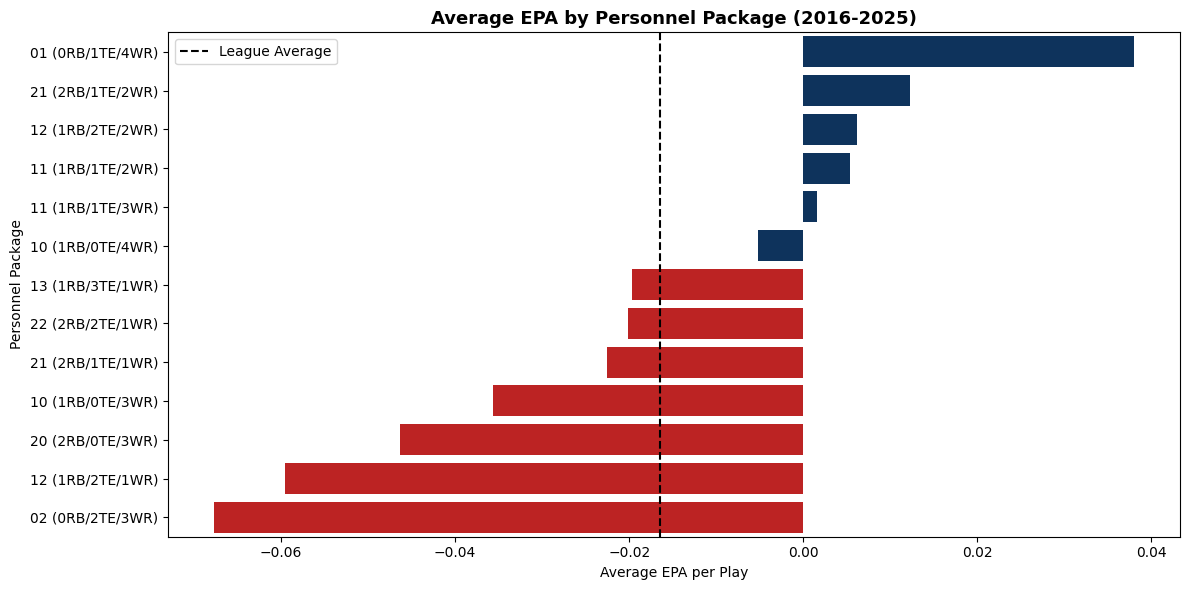

In [5]:
# Personnel package EPA (minimum 1000 plays)
personnel_epa = all_plays.groupby('personnel_package').agg(
    plays=('epa', 'count'),
    avg_epa=('epa', 'mean'),
    success_rate=('success', 'mean')
).reset_index()

personnel_epa = personnel_epa[personnel_epa['plays'] >= 1000].sort_values('avg_epa', ascending=False)

print(personnel_epa.to_string(index=False))

n = len(personnel_epa)
fig_height = max(6, n * 0.4)
league_avg = personnel_epa['avg_epa'].mean()

colors = ['#013369' if x > league_avg else '#D50A0A' for x in personnel_epa['avg_epa']]

plt.figure(figsize=(12, fig_height))
sns.barplot(data=personnel_epa, x='avg_epa', y='personnel_package',
            hue='personnel_package',
            palette=dict(zip(personnel_epa['personnel_package'], colors)),
            legend=False)
plt.axvline(x=league_avg, color='black', linestyle='--', linewidth=1.5, label='League Average')
plt.title('Average EPA by Personnel Package (2016-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Average EPA per Play')
plt.ylabel('Personnel Package')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "personnel_epa.png"), dpi=150, bbox_inches='tight')
plt.show()

![Personnel Package EPA](../outputs/figures/personnel_epa.png)

The personnel package EPA data reveals a clear pattern — spread packages with extra receivers outperform heavy run packages at the league level across all situations:

**Top performers:**
- **01 personnel (0RB/1TE/4WR — +0.038)** — empty backfield with four wide receivers generates the most EPA, forcing defenses into pure pass coverage
- **21 personnel (2RB/1TE/2WR — +0.012)** — two back sets with two receivers are surprisingly effective, offering run/pass flexibility
- **12 personnel (1RB/2TE/2WR — +0.006)** — the most complete package, balancing run support with receiving threats

**Bottom performers:**
- **02 personnel (0RB/2TE/3WR — -0.068)** — despite having no backs, this package struggles, likely used in desperation passing situations
- **12 personnel with 1 WR (-0.060)** — heavy formations without receivers are predictable and easy to defend
- **20 personnel (2RB/0TE/3WR — -0.046)** — two backs with no tight end is the least effective grouping

**The key contrast with Project 1:** In the 4th down analysis, heavy personnel packages like 12 and 21 converted at dramatically higher rates. Here across all situations, spread packages outperform. This tells us that **context matters enormously** — what works on 4th and short does not necessarily work on 1st and 10.

---

### Formation Usage by Down
How does formation selection change across different downs?

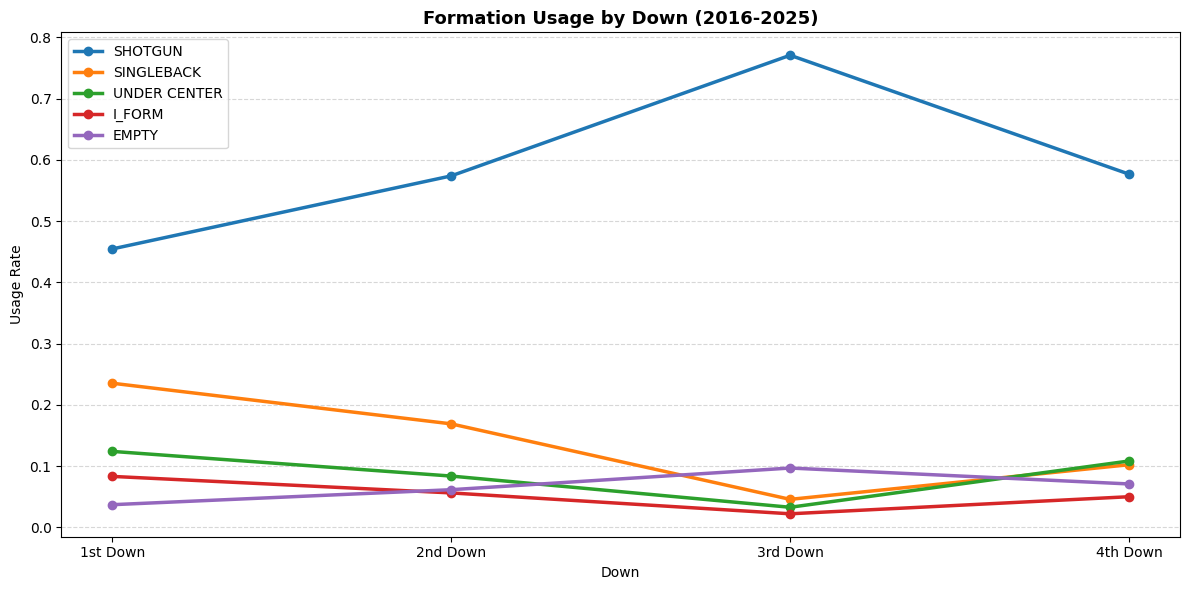

In [6]:
# Formation usage by down
down_formation = all_plays[all_plays['down'].isin([1, 2, 3, 4])].groupby(
    ['down', 'offense_formation']
).size().reset_index(name='count')

down_total = all_plays[all_plays['down'].isin([1, 2, 3, 4])].groupby('down').size().reset_index(name='total')
down_formation = down_formation.merge(down_total, on='down')
down_formation['rate'] = down_formation['count'] / down_formation['total']

top_formations = ['SHOTGUN', 'SINGLEBACK', 'UNDER CENTER', 'I_FORM', 'EMPTY']
down_formation = down_formation[down_formation['offense_formation'].isin(top_formations)]

plt.figure(figsize=(12, 6))
for formation in top_formations:
    data = down_formation[down_formation['offense_formation'] == formation]
    plt.plot(data['down'], data['rate'], marker='o', linewidth=2.5, label=formation)

plt.title('Formation Usage by Down (2016-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Down')
plt.ylabel('Usage Rate')
plt.xticks([1, 2, 3, 4], ['1st Down', '2nd Down', '3rd Down', '4th Down'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "formation_by_down.png"), dpi=150, bbox_inches='tight')
plt.show()

![Formation Usage by Down](../outputs/figures/formation_by_down.png)

Formation selection changes dramatically across downs, revealing clear strategic tendencies:

- **Shotgun climbs every down** — from 45% on 1st down to 77% on 3rd down, then drops back to 58% on 4th down. The 3rd down peak reflects how heavily teams rely on Shotgun passing concepts in obvious passing situations
- **Singleback collapses on 3rd down** — drops from 24% on 1st down to just 5% on 3rd down as teams abandon run-oriented sets in obvious passing situations
- **Under Center follows the same pattern as Singleback** — strong on early downs, nearly disappearing on 3rd down
- **Empty spikes on 3rd down** — jumps to 10% on 3rd down as teams go to pure passing sets when they need a conversion
- **I-Form nearly disappears by 3rd down** — the traditional power run formation is almost exclusively an early down call

The 4th down numbers are interesting — Shotgun drops from its 3rd down peak while Under Center and Singleback tick back up, consistent with what we found in Project 1 where traditional formations convert better on 4th down go-for-it attempts.

---

### Summary
This notebook establishes the league-wide formation landscape that all subsequent analysis will build on. Key takeaways:

1. **Shotgun dominates at 56% of all plays** and is growing, peaking at 77% on 3rd down
2. **Jumbo generates the most EPA per play** despite being used rarely, suggesting it is underutilized
3. **Spread personnel packages outperform heavy packages** across all situations, but this reverses on 4th down specifically
4. **Formation selection is highly situational** — teams use completely different formation mixes on 1st vs 3rd down
5. **Context is everything** — the same formation performs very differently depending on down, distance, and defensive alignment